In [180]:
import warnings
warnings.filterwarnings("ignore")

In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

In [182]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

In [183]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [184]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [185]:
df.shape

(7043, 21)

In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [187]:
# Changing the dtype of TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip(), errors="coerce")

In [188]:
df["SeniorCitizen"] = df["SeniorCitizen"].astype("object")

## **Understanding The Data:**

**Demographics:** 

* **CustomerID**: A unique ID that identifies each customer.
* **Gender**: The customer’s gender: Male, Female
* **Senior Citizen**: Indicates if the customer is 65 or older: Yes, No
* **Partner**: Whether the customer has a partner or not (Yes, No)
* **Dependents**: Indicates if the customer lives with any dependents: Yes, No. Dependents could be children, parents, grandparents, etc.

**Company Related Info:**

* **tenure**: Number of months the customer has stayed with the company

**Phone Services:**
* **PhoneService**: Whether the customer has a phone service or not (Yes, No)
* **MultipleLines**: Whether the customer has multiple lines or not (Yes, No, No phone service)

**Internet Services:**
* **InternetService**: Customer’s internet service provider (DSL, Fiber optic, No)
* **OnlineSecurity**: Whether the customer has online security or not (Yes, No, No internet service)
* **OnlineBackup**: Whether the customer has online backup or not (Yes, No, No internet service)
* **DeviceProtection**: Whether the customer has device protection or not (Yes, No, No internet service)
* **TechSupport**: Whether the customer has tech support or not (Yes, No, No internet service)
* **StreamingTV**: Whether the customer has streaming TV or not (Yes, No, No internet service)
* **StreamingMovies**: Whether the customer has streaming movies or not (Yes, No, No internet service)

**Membership and Billing:**
* **Contract**: The contract term of the customer (Month-to-month, One year, Two year)
* **PaperlessBilling**: Whether the customer has paperless billing or not (Yes, No)
* **PaymentMethod**: The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))

**Chargers:**
* **MonthlyCharges**: The amount charged to the customer monthly
* **TotalCharges**: The total amount charged to the customer

In [189]:
numerical_col = []
categorical_col = []

for i in df.columns:
    if(df[i].dtype == 'object'):
        categorical_col.append(i)
    else:
        numerical_col.append(i)

print(f"Total number of numerical columns is {len(numerical_col)}, And they are : {numerical_col}")
print(f"Total number of categorical columns is {len(categorical_col)}, And they are : {categorical_col}")

Total number of numerical columns is 3, And they are : ['tenure', 'MonthlyCharges', 'TotalCharges']
Total number of categorical columns is 18, And they are : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


## **Univariate Analysis:**

**Numerical Columns:**

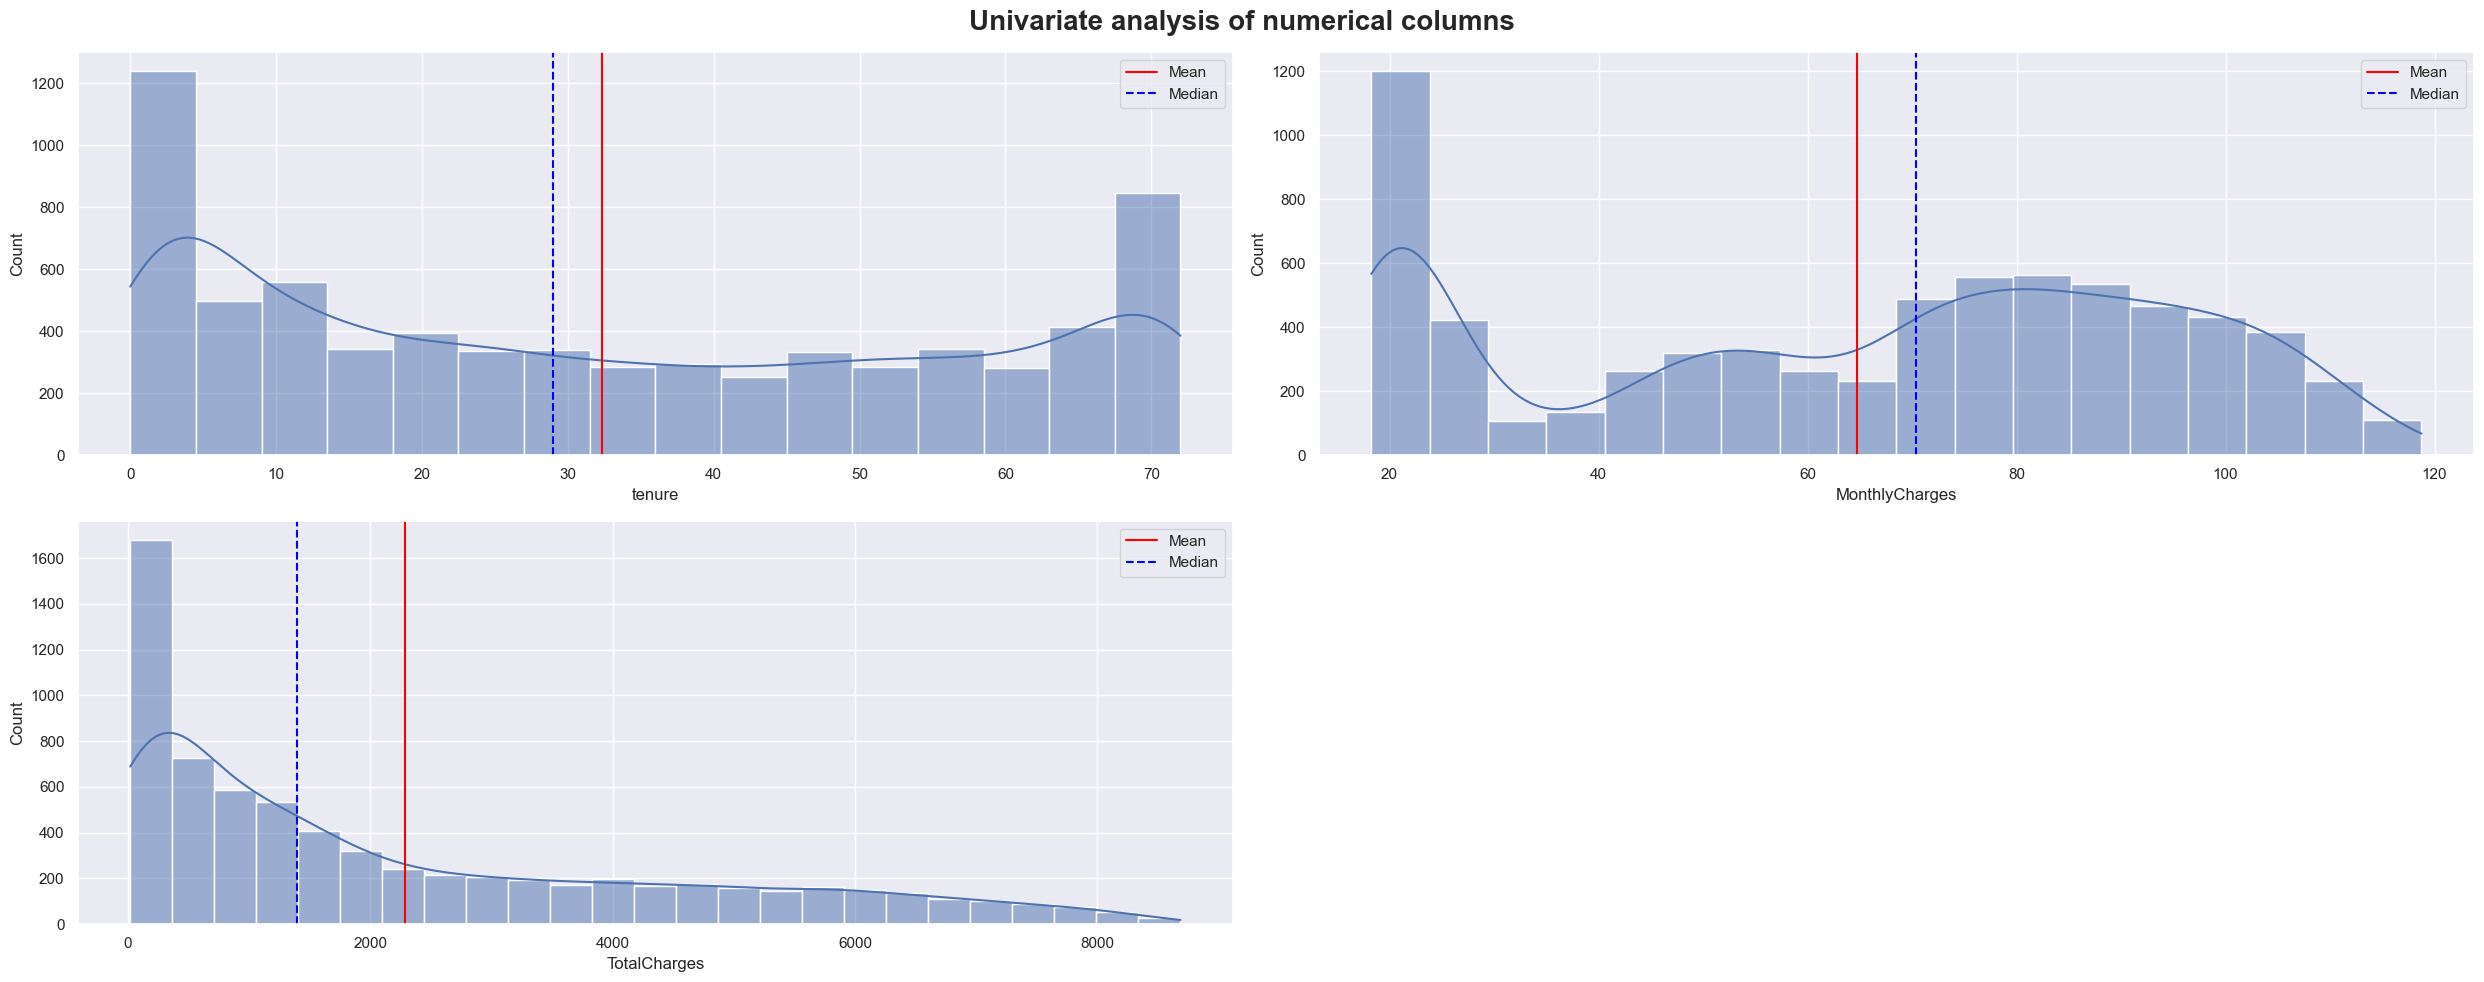

In [190]:
plt.figure(figsize=(25,10))
plt.suptitle("Univariate analysis of numerical columns", fontsize = 20, fontweight = 'bold')

for i in range(0, 3):
    plt.subplot(2, 2, i+1)
    plt.xlabel(numerical_col[i])
    sns.histplot(df[numerical_col[i]], kde = True)
    plt.axvline(df[numerical_col[i]].mean(), color = 'red', linestyle = '-', label = 'Mean')
    plt.axvline(df[numerical_col[i]].median(), color = 'blue', linestyle = '--', label = 'Median')
    plt.legend()
    plt.tight_layout()

plt.show()

<Axes: title={'center': 'No Churn'}, xlabel='tenure', ylabel='Count'>

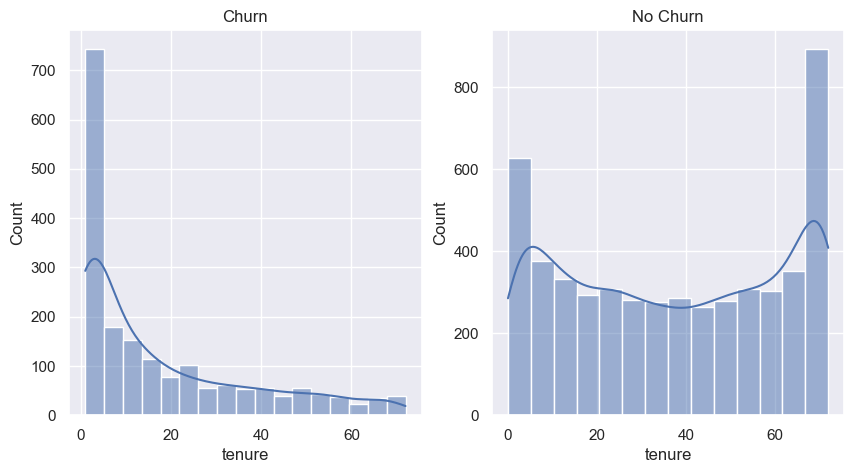

In [191]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Churn")
sns.histplot(x = df[df["Churn"] == "Yes"]["tenure"], kde = True)
plt.subplot(1,2,2)
plt.title("No Churn")
sns.histplot(x = df[df["Churn"] != "Yes"]["tenure"], kde = True)

**Observation: The new customers tend to leave more**

<Axes: xlabel='tenure', ylabel='Density'>

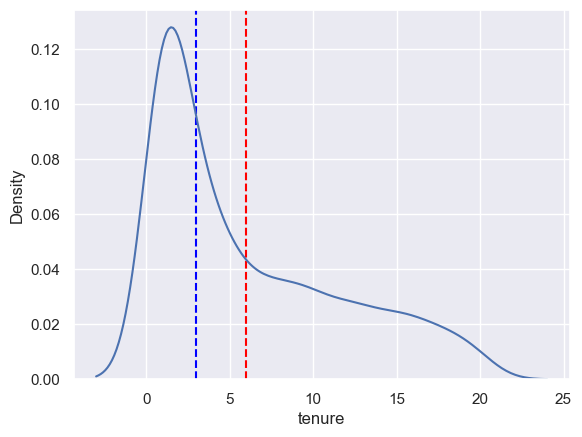

In [192]:

plt.axvline(x = 3, color = 'blue', linestyle = "--")
plt.axvline(x = 6, color = 'red', linestyle = "--")
sns.kdeplot(
    x = df[(df["Churn"] == "Yes") & (df["tenure"] <= 20)]["tenure"]
)

Customers with tenure <=3 Months tend to leave more

<Axes: title={'center': 'No Churn'}, xlabel='MonthlyCharges', ylabel='Count'>

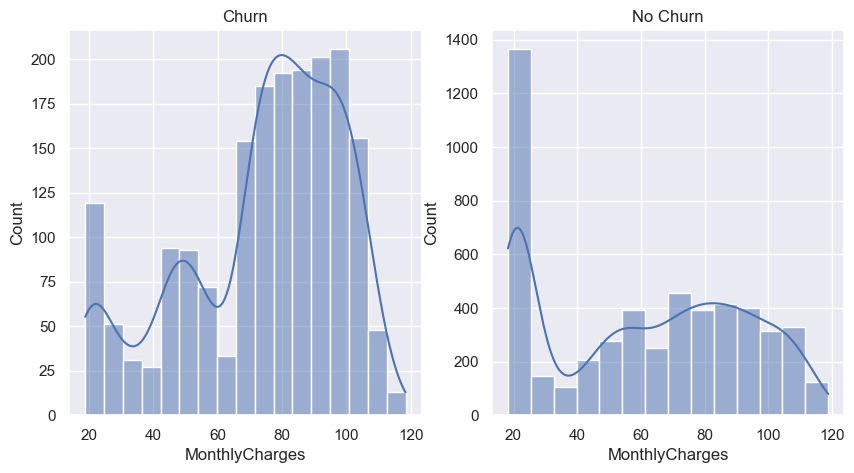

In [193]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Churn")
sns.histplot(x = df[df["Churn"] == "Yes"]["MonthlyCharges"], kde = True)
plt.subplot(1,2,2)
plt.title("No Churn")
sns.histplot(x = df[df["Churn"] != "Yes"]["MonthlyCharges"], kde = True)

<Axes: title={'center': 'No Churn'}, xlabel='TotalCharges', ylabel='Count'>

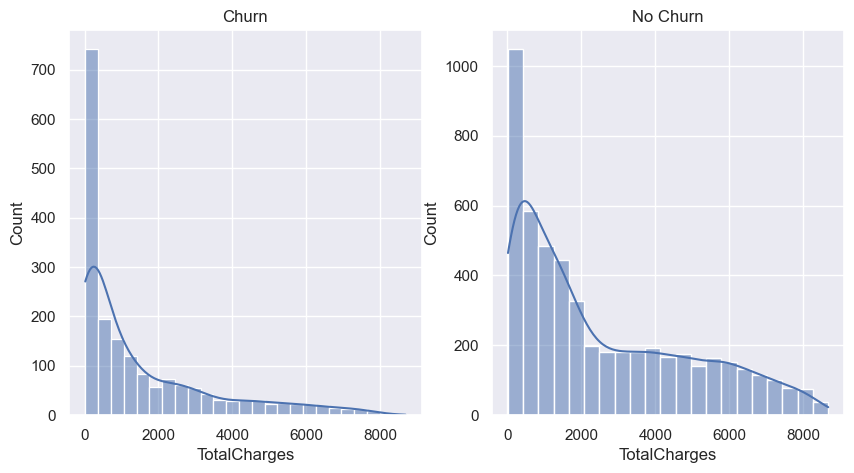

In [194]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Churn")
sns.histplot(x = df[df["Churn"] == "Yes"]["TotalCharges"], kde = True)
plt.subplot(1,2,2)
plt.title("No Churn")
sns.histplot(x = df[df["Churn"] != "Yes"]["TotalCharges"], kde = True)

<Axes: xlabel='tenure', ylabel='Density'>

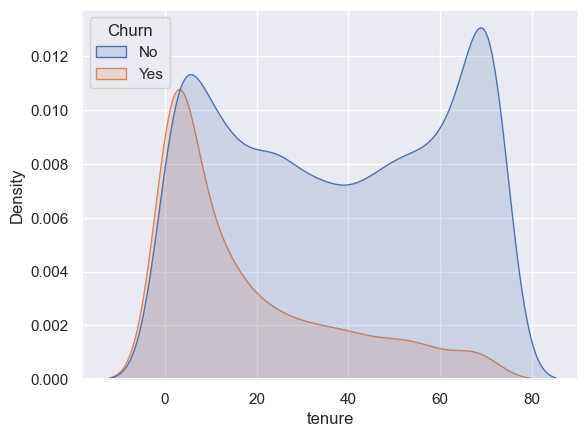

In [195]:
sns.kdeplot(
    data=df,
    x="tenure",
    hue="Churn",
    fill = True,
    alpha = 0.2
)

<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

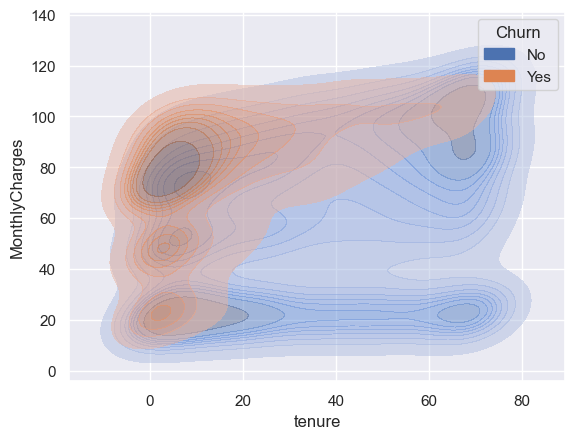

In [196]:
sns.kdeplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    fill=True,
    alpha=0.5,        # 🔻 lower transparency (more see-through)
    linewidth=5     # 🔥 bold border
)

New customers paying high monthly charges tend to leave more (i.e. Low tenure and High Monthly charges -> High Risk Zone)

<Axes: xlabel='tenure', ylabel='TotalCharges'>

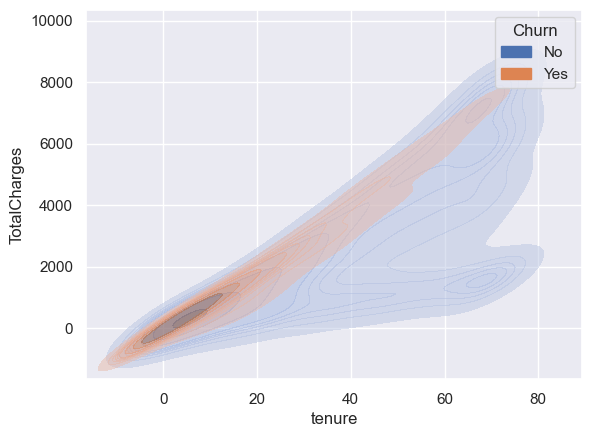

In [197]:
sns.kdeplot(
    data=df,
    x="tenure",
    y="TotalCharges",
    hue="Churn",
    fill=True,
    alpha=0.5,        
    linewidth=5     
)

<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

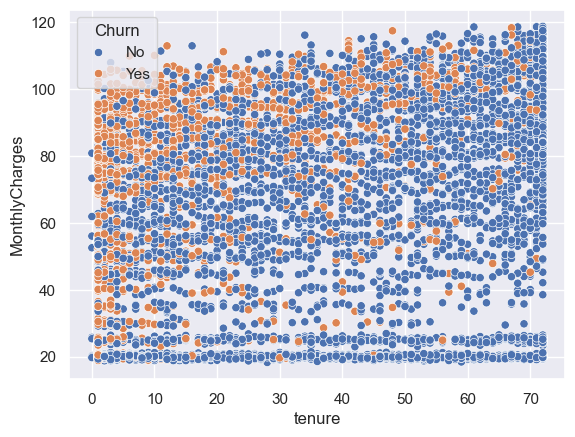

In [198]:
sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn"
)

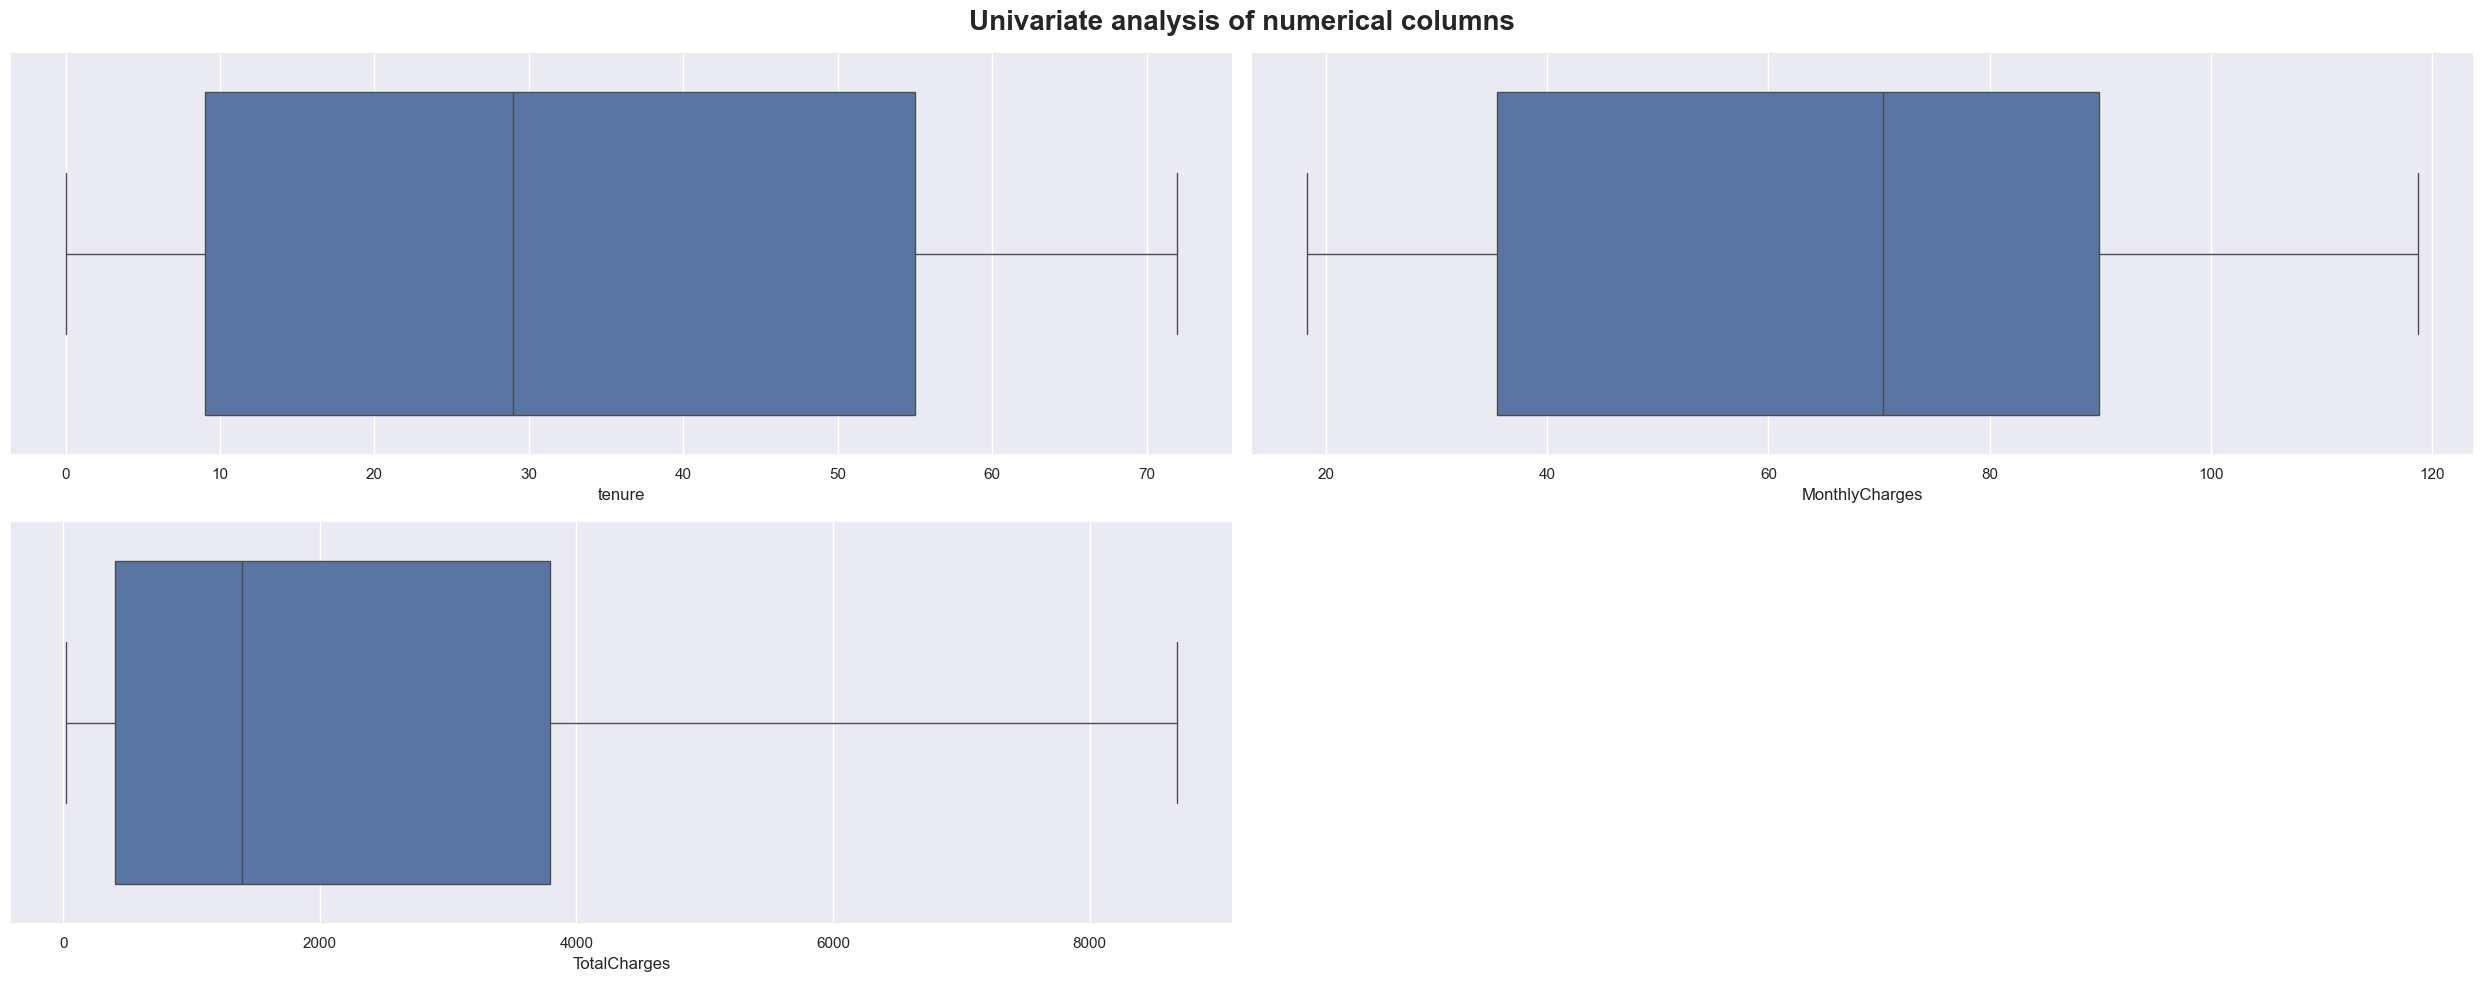

In [199]:
plt.figure(figsize=(25,10))
plt.suptitle("Univariate analysis of numerical columns", fontsize = 20, fontweight = 'bold')

for i in range(0, 3):
    plt.subplot(2, 2, i+1)
    plt.xlabel(numerical_col[i])
    sns.boxplot(x = df[numerical_col[i]])
    
plt.tight_layout()
plt.show()

No Outliers

**Categorical Columns:**

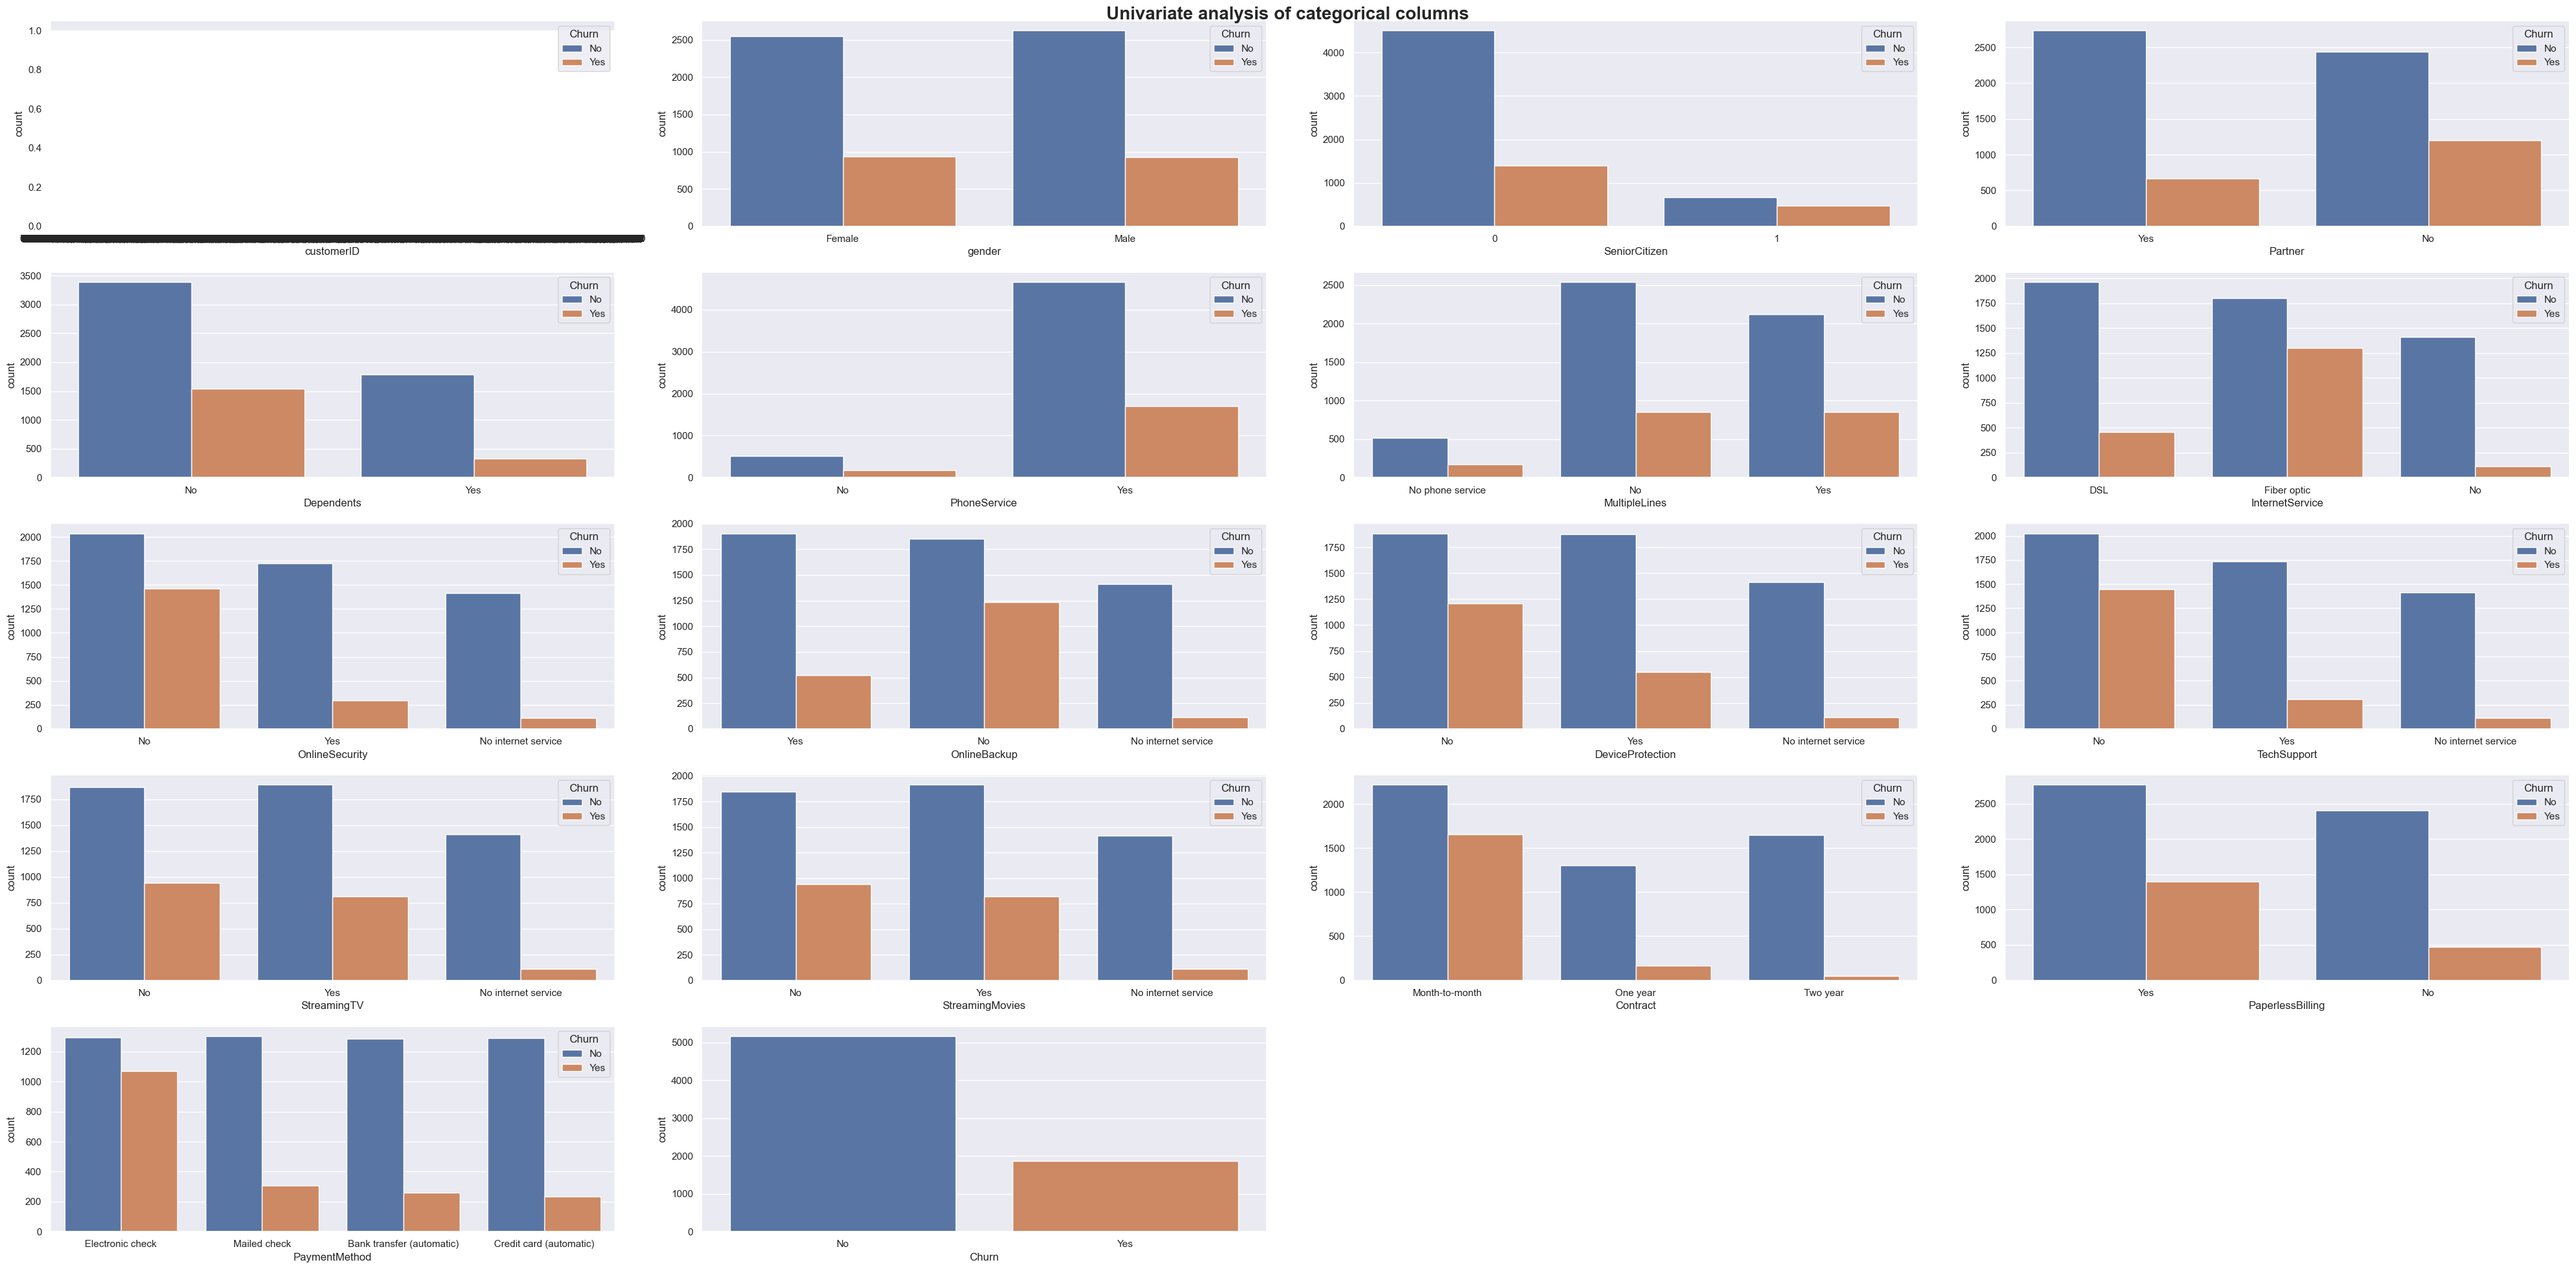

In [200]:
plt.figure(figsize=(40,20))
plt.suptitle("Univariate analysis of categorical columns", fontsize=20, fontweight='bold')

for i, col in enumerate(categorical_col):
    plt.subplot(5, 4, i+1)
    sns.countplot(df, x=col, hue = "Churn")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

* Observations:
    - Customers with no partners has higher Churn and they are the least cutomers
    - Dependent customers are high in number and high in Churn
    - Most of the customers have phone services and also high in Churn
    - Customers with multiline and single line Phone service doesn't show any differnce in Churn (Highly Colrelated)
    - Customers with Fiber optic Internet Service show High Churn than others
    - Customers without online security shows high Churn
    - Customers without online backup shows high churn
    - Customers without Device Protection shoes High Churn
    - Customers without tech support shows high Churn
    - Both Tv Streaming and Non TV streaming Customers Shows High Churn
    - Both Movie Streaming and Non Movie streaming Customers Shows High Churn
    - Monthly membership customers tend to have High Churn
    - Paperless billing and Electronic check payment service customers have High Churn

In [201]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

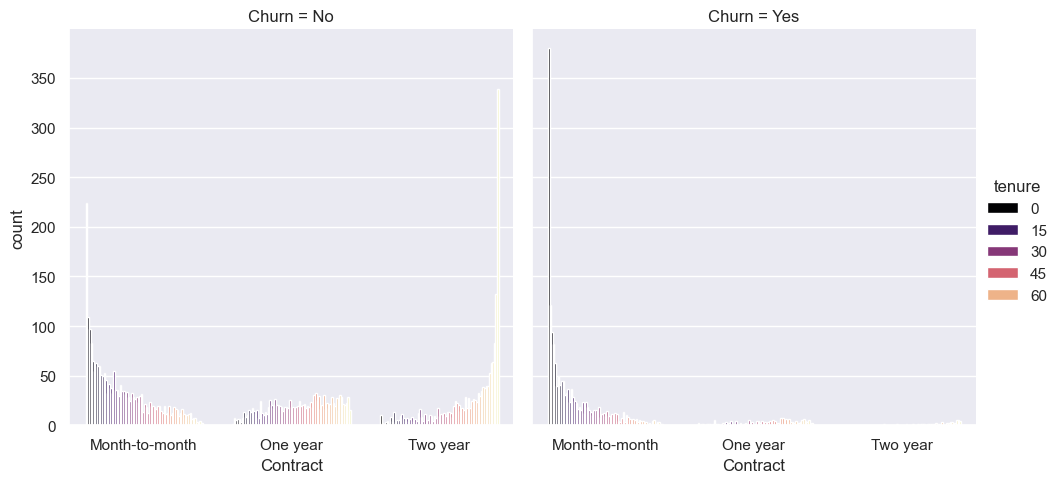

In [202]:
sns.catplot(df, x = "Contract", hue = "tenure", col = "Churn", kind = "count", palette='magma')

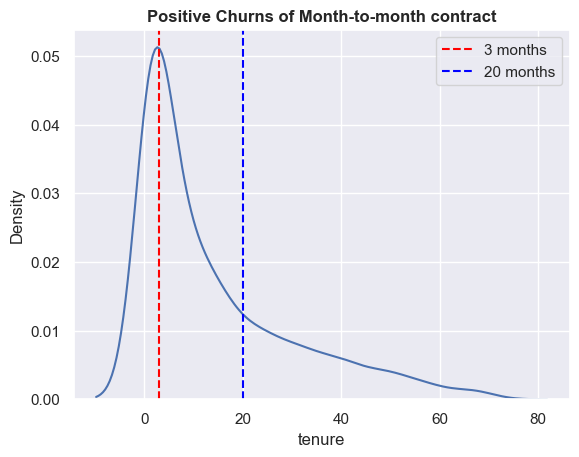

In [203]:
sns.kdeplot(x = df[(df["Contract"] == "Month-to-month") & (df["Churn"] == "Yes")]["tenure"])
plt.axvline(x = 3, label = "3 months", color = "red", linestyle = "--")
plt.axvline(x = 20, label = "20 months", color = "blue", linestyle = "--")
plt.title("Positive Churns of Month-to-month contract", fontweight = 'bold')
plt.legend()

Customers who are new and selecting month to month membership have a higher trend towards Churn (i.e. Low tenure + Month_to_month -> High risk)

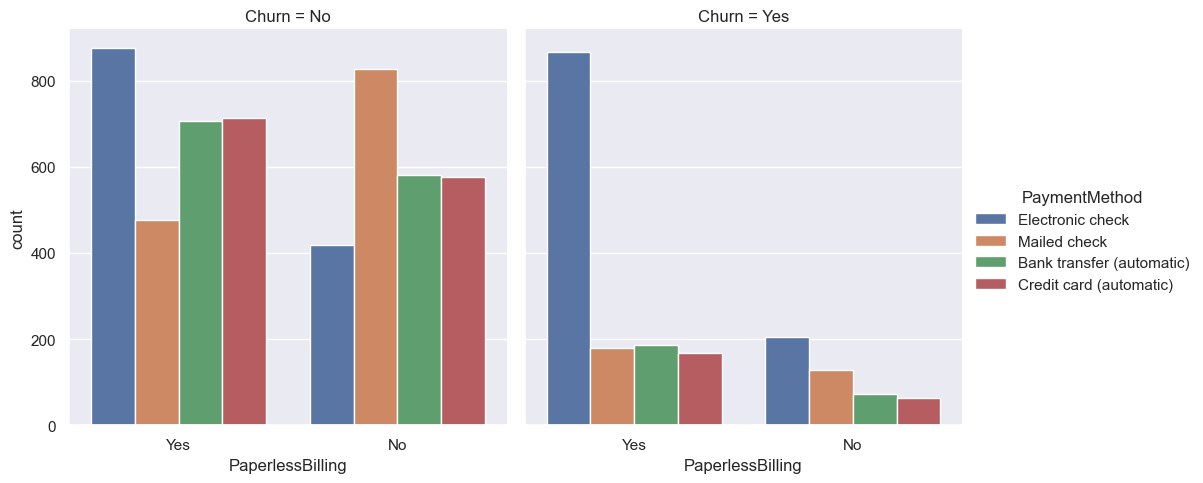

In [204]:
sns.catplot(df, x = "PaperlessBilling", hue = "PaymentMethod", col = "Churn", kind = "count")

Customer who pay in non automated payment systems tend to leave more . (i.e. PaperlessBilling + Electronic -> High Risk)

<Axes: ylabel='count'>

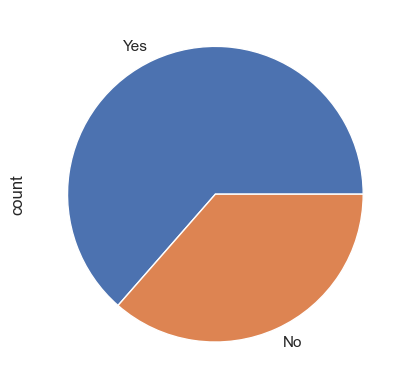

In [205]:
df.query("(InternetService ==  'Fiber optic') & (OnlineSecurity == 'No') & (OnlineBackup == 'No') & (DeviceProtection == 'No') & (TechSupport == 'No')")["Churn"].value_counts().plot(kind = 'pie')

* Business Insights:
    - The Fiber Optic Internet Service is responsible in dissatisfying the customers, which should be improved
    - The customers who are taking services without security, backup and support tend to have high Churn rate
    - Combo offers with security and backup service might be helpful for the customers

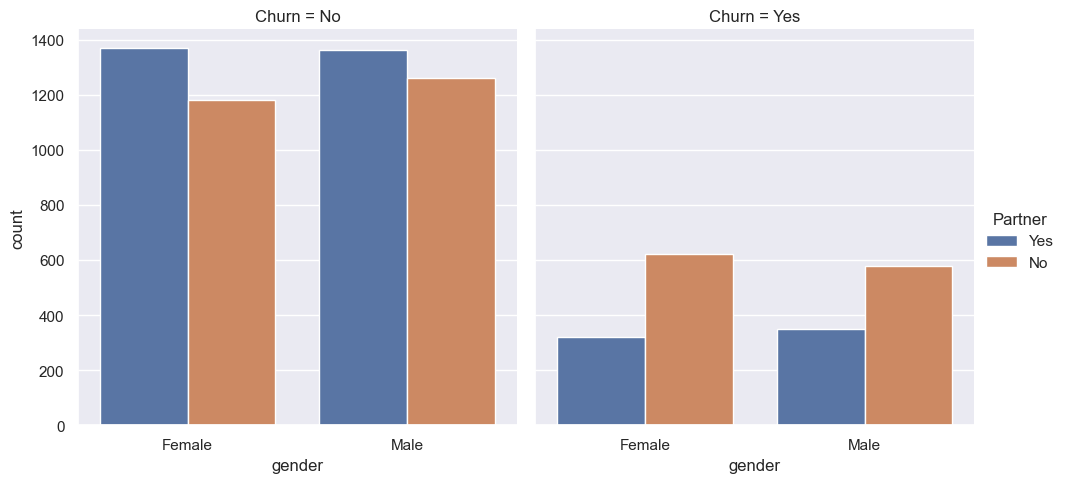

In [206]:
sns.catplot(df, x = "gender", hue = "Partner", col= "Churn", kind= "count")

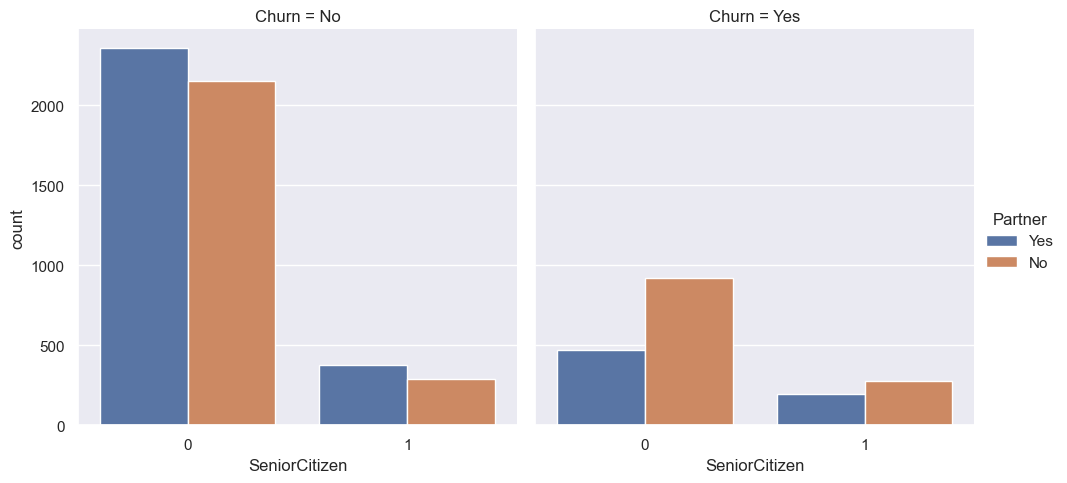

In [207]:
sns.catplot(df, x = "SeniorCitizen", hue = "Partner", col= "Churn", kind= "count")

Senior Citizen without support of partners tend to have high churn rate. (i.e. Senior Citizen with no partner -> risky)

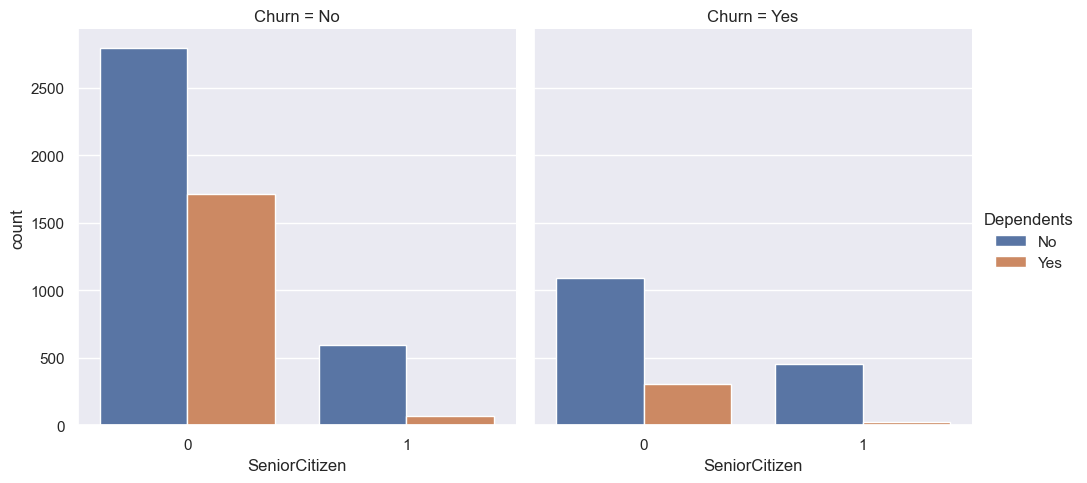

In [208]:
sns.catplot(df, x = "SeniorCitizen", hue = "Dependents", col= "Churn", kind= "count")

Senior Citizen without any dependecies tend to have high churn rate. (i.e. Senior Citizen + No dependents -> risky)

<Axes: xlabel='SeniorCitizen', ylabel='count'>

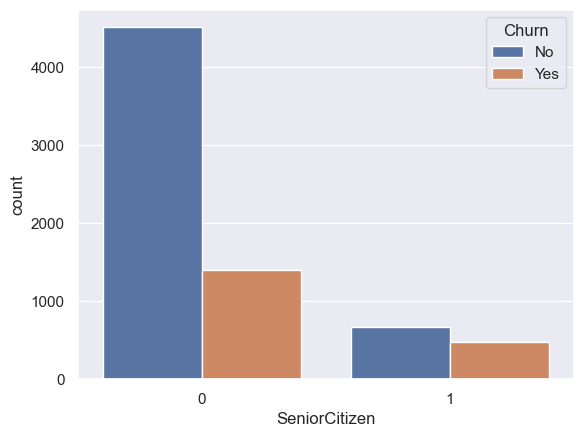

In [209]:
sns.countplot(df, x = 'SeniorCitizen', hue = 'Churn')

## **Data Cleaning:**

In [210]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
                    ..
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
Length: 21, dtype: int64

In [211]:
# Filling total charges with median as it is a skewed data
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

In [212]:
#Checking duplicates
df.duplicated().sum()

np.int64(0)

## **Feature Engineering:**

* After the EDA the features that seemed to be valuable are:
    - new_customer : tenure <= 3
    - tenure_log and tenure_sqrt : for feeding the non-linear behaviour of the tenure to the models
    - low_tenure_high_monthly_charge : tenure <= 20 and monthly_charge >= 60
    - low_tenure_month : tenure <= 20 and contract = Month-to-month
    - non_automated_payment : PaperlessBilling = Yes and PaymentMethod = Electronic check
    - poor_service : Services without security, bacup and tech support
    - senior_no_partner : Senior Citizens without partners
    - senior_no_dependets : Senior Citizens without dependets
 

In [213]:
#Printing The unique values of each column:
for i in df.columns:
    print(i)
    print(df[i].unique())
    print("*"*30)

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
******************************
gender
['Female' 'Male']
******************************
SeniorCitizen
[0 1]
******************************
Partner
['Yes' 'No']
******************************
Dependents
['No' 'Yes']
******************************
tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
******************************
PhoneService
['No' 'Yes']
******************************
MultipleLines
['No phone service' 'No' 'Yes']
******************************
InternetService
['DSL' 'Fiber optic' 'No']
******************************
OnlineSecurity
['No' 'Yes' 'No internet service']
******************************
OnlineBackup
['Yes' 'No' 'No internet service']
******************************
DeviceProtection
['No' 'Yes' 

In [214]:
df["PhoneService"].unique()

array(['No', 'Yes'], dtype=object)

In [215]:
df["MultipleLines"].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [216]:
## Changing the PhoneService and MultipleLines as One:
df["phone_service"] = df["PhoneService"].map({"Yes": 1, "No": 0})

df.drop(["PhoneService", "MultipleLines"], axis = 1, inplace=True)

In [217]:
df["new_customer"] = np.where(df["tenure"] <= 3, 1, 0)

In [218]:
df["tenure_log"] = np.log(df["tenure"])

In [219]:
df["tenure_sqrt"] = np.sqrt(df["tenure"]+5) 

<Axes: xlabel='tenure_sqrt', ylabel='Density'>

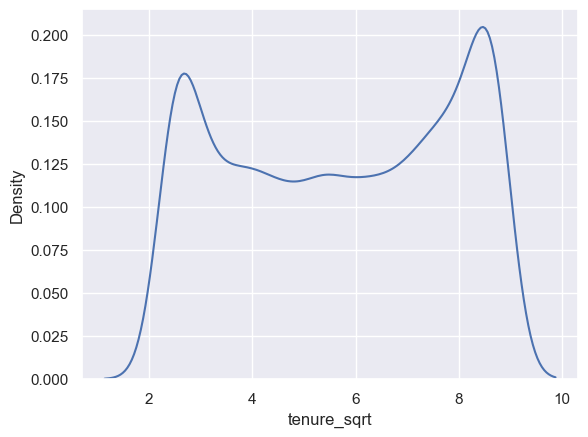

In [220]:
sns.kdeplot(df["tenure_sqrt"])

In [221]:
df["Low_tenure_high_monthlyCharge"] = np.where((df["tenure"] <= 20) & (df["MonthlyCharges"] >60), 1, 0) 

In [222]:
df["Low_tenure_month_contract"] = np.where((df["tenure"] <= 20) & (df["Contract"] =="Month-to-month"), 1, 0) 

In [223]:
df["non_automated_billing"] = np.where((df["PaperlessBilling"] == "Yes") & (df["PaymentMethod"] == "Electronic check"), 1, 0) 

In [224]:
df["poor_service_combo"] = np.where((df["InternetService"] == "Fiber optic") & (df["OnlineSecurity"] == "No") & 
                                    (df["OnlineBackup"] == "No") & (df["DeviceProtection"] == "No") & 
                                    (df["TechSupport"] == "No"), 1, 0)

In [225]:
df["senior_no_partner"] = np.where((df["SeniorCitizen"] == 1) & (df["Partner"] == "No"), 1, 0) 

In [226]:
df["senior_no_dependents"] = np.where((df["SeniorCitizen"] == 1) & (df["Dependents"] == "No"), 1, 0) 

In [227]:
df = df.drop(columns=["customerID"], axis = 1)

In [228]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,phone_service,new_customer,tenure_log,tenure_sqrt,Low_tenure_high_monthlyCharge,Low_tenure_month_contract,non_automated_billing,poor_service_combo,senior_no_partner,senior_no_dependents
0,Female,0,Yes,No,1,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,1,0.000000,2.449490,0,1,1,0,0,0
1,Male,0,No,No,34,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,1,0,3.526361,6.244998,0,0,0,0,0,0
2,Male,0,No,No,2,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,1,0.693147,2.645751,0,1,0,0,0,0
3,Male,0,No,No,45,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,0,3.806662,7.071068,0,0,0,0,0,0
4,Female,0,No,No,2,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,1,0.693147,2.645751,1,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,1,0,3.178054,5.385165,0,0,0,0,0,0
7039,Female,0,Yes,Yes,72,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,1,0,4.276666,8.774964,0,0,0,0,0,0
7040,Female,0,Yes,Yes,11,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,0,2.397895,4.000000,0,1,1,0,0,0
7041,Male,1,Yes,No,4,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1,0,1.386294,3.000000,1,1,0,1,0,1


In [229]:
df["no_internet"] = np.where((df.InternetService == "No") |
                             (df.OnlineSecurity == "No internet service") |
                             (df.OnlineBackup == "No internet service") |
                             (df.DeviceProtection == "No internet service") |
                             (df.TechSupport == "No internet service") |
                             (df.StreamingTV == "No internet service") |
                             (df.StreamingMovies == "No internet service") , 1, 0)

In [230]:
#Encoding

df_encoded = pd.get_dummies(df, columns=["InternetService", "OnlineBackup", "OnlineSecurity", "DeviceProtection", "TechSupport", "StreamingTV",	"StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"], dtype=int)

In [231]:
df_encoded

,gender,SeniorCitizen,Partner,Dependents,tenure,MonthlyCharges,TotalCharges,Churn,phone_service,new_customer,tenure_log,tenure_sqrt,Low_tenure_high_monthlyCharge,Low_tenure_month_contract,non_automated_billing,poor_service_combo,senior_no_partner,senior_no_dependents,no_internet,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,Female,0,Yes,No,1,29.85,29.85,No,0,1,0.000000,2.449490,0,1,1,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
1,Male,0,No,No,34,56.95,1889.50,No,1,0,3.526361,6.244998,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1
2,Male,0,No,No,2,53.85,108.15,Yes,1,1,0.693147,2.645751,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1
3,Male,0,No,No,45,42.30,1840.75,No,0,0,3.806662,7.071068,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,1,0,1,0,0,0
4,Female,0,No,No,2,70.70,151.65,Yes,1,1,0.693147,2.645751,1,1,1,1,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,84.80,1990.50,No,1,0,3.178054,5.385165,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1
7039,Female,0,Yes,Yes,72,103.20,7362.90,No,1,0,4.276666,8.774964,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,0,1,0,0,1,0,1,0,0
7040,Female,0,Yes,Yes,11,29.60,346.45,No,0,0,2.397895,4.000000,0,1,1,0,0,0,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
7041,Male,1,Yes,No,4,74.40,306.60,Yes,1,0,1.386294,3.000000,1,1,0,1,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1


In [232]:
df_encoded["SeniorCitizen"] = df_encoded["SeniorCitizen"].astype(int)

In [233]:
df_encoded["gender"] = df_encoded["gender"].map({"Female": 0, "Male" : 1})
df_encoded["Partner"] = df_encoded["Partner"].map({"No": 0, "Yes" : 1})
df_encoded["Dependents"] = df_encoded["Dependents"].map({"No": 0, "Yes" : 1})
df_encoded["Churn"] = df_encoded["Churn"].map({"No": 0, "Yes" : 1})

In [234]:
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,MonthlyCharges,TotalCharges,Churn,phone_service,new_customer,tenure_log,tenure_sqrt,Low_tenure_high_monthlyCharge,Low_tenure_month_contract,non_automated_billing,poor_service_combo,senior_no_partner,senior_no_dependents,no_internet,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,29.85,29.85,0,0,1,0.000000,2.449490,0,1,1,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
1,1,0,0,0,34,56.95,1889.50,0,1,0,3.526361,6.244998,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1
2,1,0,0,0,2,53.85,108.15,1,1,1,0.693147,2.645751,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1
3,1,0,0,0,45,42.30,1840.75,0,0,0,3.806662,7.071068,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,1,0,1,0,0,0
4,0,0,0,0,2,70.70,151.65,1,1,1,0.693147,2.645751,1,1,1,1,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0


In [235]:
#Dropping unneccesary column:
df_reduced = df_encoded.drop(columns=[ "InternetService_No", "OnlineBackup_No internet service", "OnlineSecurity_No internet service", 
                              "DeviceProtection_No internet service", "TechSupport_No internet service", "StreamingTV_No internet service",
                              "StreamingMovies_No internet service"], axis =1)

In [236]:
df_reduced

,gender,SeniorCitizen,Partner,Dependents,tenure,MonthlyCharges,TotalCharges,Churn,phone_service,new_customer,tenure_log,tenure_sqrt,Low_tenure_high_monthlyCharge,Low_tenure_month_contract,non_automated_billing,poor_service_combo,senior_no_partner,senior_no_dependents,no_internet,InternetService_DSL,InternetService_Fiber optic,OnlineBackup_No,OnlineBackup_Yes,OnlineSecurity_No,OnlineSecurity_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,29.85,29.85,0,0,1,0.000000,2.449490,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,0,1,0,0,1,0
1,1,0,0,0,34,56.95,1889.50,0,1,0,3.526361,6.244998,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,1,0,1,0,1,0,0,1,0,1,0,0,0,0,1
2,1,0,0,0,2,53.85,108.15,1,1,1,0.693147,2.645751,0,1,0,0,0,0,0,1,0,0,1,0,1,1,0,1,0,1,0,1,0,1,0,0,0,1,0,0,0,1
3,1,0,0,0,45,42.30,1840.75,0,0,0,3.806662,7.071068,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,0,1,1,0,1,0,0,1,0,1,0,1,0,0,0
4,0,0,0,0,2,70.70,151.65,1,1,1,0.693147,2.645751,1,1,1,1,0,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,84.80,1990.50,0,1,0,3.178054,5.385165,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,0,1
7039,0,0,1,1,72,103.20,7362.90,0,1,0,4.276666,8.774964,0,0,0,0,0,0,0,0,1,0,1,1,0,0,1,1,0,0,1,0,1,0,1,0,0,1,0,1,0,0
7040,0,0,1,1,11,29.60,346.45,0,0,0,2.397895,4.000000,0,1,1,0,0,0,0,1,0,1,0,0,1,1,0,1,0,1,0,1,0,1,0,0,0,1,0,0,1,0
7041,1,1,1,0,4,74.40,306.60,1,1,0,1.386294,3.000000,1,1,0,1,0,1,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,1,0,0,0,1


In [237]:
df["non_automated_billing"].unique()

array([1, 0])

In [238]:
df_reduced["tenure_log"].sort_values()

936         -inf
753         -inf
5218        -inf
3826        -inf
488         -inf
          ...   
6400    4.276666
6386    4.276666
7037    4.276666
7039    4.276666
28      4.276666
Name: tenure_log, Length: 7043, dtype: float64

In [239]:
df_reduced["tenure_log"] = np.log(1 + df["tenure"])

In [240]:
df_reduced.to_csv("modified_data2.csv", index=False)

In [241]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
df_reduced[["tenure", 'MonthlyCharges', 'TotalCharges', 'tenure_log', 'tenure_sqrt']] = pd.DataFrame(mms.fit_transform(df_reduced[["tenure", 'MonthlyCharges', 'TotalCharges', 'tenure_log', 'tenure_sqrt']]), columns = ["tenure", 'MonthlyCharges', 'TotalCharges', 'tenure_log', 'tenure_sqrt'])

In [242]:
df_reduced.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,MonthlyCharges,TotalCharges,Churn,phone_service,new_customer,tenure_log,tenure_sqrt,Low_tenure_high_monthlyCharge,Low_tenure_month_contract,non_automated_billing,poor_service_combo,senior_no_partner,senior_no_dependents,no_internet,InternetService_DSL,InternetService_Fiber optic,OnlineBackup_No,OnlineBackup_Yes,OnlineSecurity_No,OnlineSecurity_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,0.013889,0.115423,0.001275,0,0,1,0.161555,0.032639,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,0,1,0,0,1,0
1,1,0,0,0,0.472222,0.385075,0.215867,0,1,0,0.828664,0.613090,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,1,0,1,0,1,0,0,1,0,1,0,0,0,0,1
2,1,0,0,0,0.027778,0.354229,0.010310,1,1,1,0.256059,0.062653,0,1,0,0,0,0,0,1,0,0,1,0,1,1,0,1,0,1,0,1,0,1,0,0,0,1,0,0,0,1
3,1,0,0,0,0.625000,0.239303,0.210241,0,0,0,0.892362,0.739421,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,0,1,1,0,1,0,0,1,0,1,0,1,0,0,0
4,0,0,0,0,0.027778,0.521891,0.015330,1,1,1,0.256059,0.062653,1,1,1,1,0,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,1,0,0,1,0


In [243]:
#Printing The unique values of each column:
for i in df_reduced.columns:
    print(i)
    print(df_reduced[i].unique())
    print("*"*30)

gender
[0 1]
******************************
SeniorCitizen
[0 1]
******************************
Partner
[1 0]
******************************
Dependents
[0 1]
******************************
tenure
[0.01388889 0.47222222 0.02777778 0.625      0.11111111 0.30555556
 0.13888889 0.38888889 0.86111111 0.18055556 0.22222222 0.80555556
 0.68055556 0.34722222 0.95833333 0.72222222 0.98611111 0.29166667
 0.16666667 0.41666667 0.65277778 1.         0.23611111 0.375
 0.06944444 0.63888889 0.15277778 0.97222222 0.875      0.59722222
 0.20833333 0.83333333 0.25       0.91666667 0.125      0.04166667
 0.43055556 0.69444444 0.88888889 0.77777778 0.09722222 0.58333333
 0.48611111 0.66666667 0.40277778 0.90277778 0.52777778 0.94444444
 0.44444444 0.76388889 0.51388889 0.5        0.56944444 0.08333333
 0.05555556 0.45833333 0.93055556 0.31944444 0.79166667 0.84722222
 0.19444444 0.27777778 0.73611111 0.55555556 0.81944444 0.33333333
 0.61111111 0.26388889 0.75       0.70833333 0.36111111 0.
 0.54166667]
*

In [244]:
X = df_reduced.drop(columns = ["Churn"], axis = 1)
Y = df_reduced["Churn"]

In [245]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,MonthlyCharges,TotalCharges,phone_service,new_customer,tenure_log,tenure_sqrt,Low_tenure_high_monthlyCharge,Low_tenure_month_contract,non_automated_billing,poor_service_combo,senior_no_partner,senior_no_dependents,no_internet,InternetService_DSL,InternetService_Fiber optic,OnlineBackup_No,OnlineBackup_Yes,OnlineSecurity_No,OnlineSecurity_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,0.013889,0.115423,0.001275,0,1,0.161555,0.032639,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,0,1,0,0,1,0
1,1,0,0,0,0.472222,0.385075,0.215867,1,0,0.828664,0.613090,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,1,0,1,0,1,0,0,1,0,1,0,0,0,0,1
2,1,0,0,0,0.027778,0.354229,0.010310,1,1,0.256059,0.062653,0,1,0,0,0,0,0,1,0,0,1,0,1,1,0,1,0,1,0,1,0,1,0,0,0,1,0,0,0,1
3,1,0,0,0,0.625000,0.239303,0.210241,0,0,0.892362,0.739421,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,0,1,1,0,1,0,0,1,0,1,0,1,0,0,0
4,0,0,0,0,0.027778,0.521891,0.015330,1,1,0.256059,0.062653,1,1,1,1,0,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,0.333333,0.662189,0.227521,1,0,0.750240,0.481595,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,0,1
7039,0,0,1,1,1.000000,0.845274,0.847461,1,0,1.000000,1.000000,0,0,0,0,0,0,0,0,1,0,1,1,0,0,1,1,0,0,1,0,1,0,1,0,0,1,0,1,0,0
7040,0,0,1,1,0.152778,0.112935,0.037809,0,0,0.579170,0.269760,0,1,1,0,0,0,0,1,0,1,0,0,1,1,0,1,0,1,0,1,0,1,0,0,0,1,0,0,1,0
7041,1,1,1,0,0.055556,0.558706,0.033210,1,0,0.375120,0.116829,1,1,0,1,0,1,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,1,0,0,0,1


In [246]:
Y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

## Model Training

## Logistic Regression:

In [247]:
model_scores = {'model':[], "accuracy":[], "precision":[], "recall":[], 'f1':[], 'roc_auc':[]}

In [248]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [249]:
from sklearn.model_selection import cross_val_score,StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [250]:
from sklearn.linear_model import LogisticRegression
model_lg = LogisticRegression()
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

model_scores['model'].append("Logistic Regression")

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', model_lg)
])

for i in scoring:
    scores = cross_val_score(pipeline, X, Y, cv=skf, scoring=i)
    print(f"{i}: {scores.mean()}")
    model_scores[i].append(scores.mean())

accuracy: 0.7858822936814958
precision: 0.5815082566581744
recall: 0.6966103156805245
f1: 0.6332649766989612
roc_auc: 0.8455651544929198


## Random Forest:

In [251]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report



In [252]:

model_rf = RandomForestClassifier(n_estimators=200, max_depth=10, criterion="entropy", min_samples_leaf=3, min_samples_split=5)
for i in scoring:
    print(f"{i}: {cross_val_score(model_rf, X, Y, cv = skf, scoring=i).mean()}")

accuracy: 0.8029223081882655
precision: 0.6643401685713022
recall: 0.5141596227933988
f1: 0.5790887479290511
roc_auc: 0.8458621354530923


In [253]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.2, random_state=42)

In [254]:
#Trying Under_Sampling:
rus = RandomUnderSampler(random_state=42)
X_re, Y_re = rus.fit_resample(X_train, Y_train)

In [255]:
Y_re.value_counts()

Churn
0    1496
1    1496
Name: count, dtype: int64

In [256]:
#Trying Undersampling
model_rf_us = RandomForestClassifier(n_estimators=200, max_depth=20, criterion="entropy", min_samples_leaf=8, min_samples_split=5)
model_rf_us.fit(X_re, Y_re)
pred = model_rf_us.predict(X_test)
print(classification_report(pred, Y_test))

              precision    recall  f1-score   support

           0       0.74      0.92      0.82       829
           1       0.82      0.53      0.64       580

    accuracy                           0.76      1409
   macro avg       0.78      0.72      0.73      1409
weighted avg       0.77      0.76      0.75      1409



In [257]:
#Waited sampling
model_rf_ws = RandomForestClassifier(n_estimators=200, max_depth=20, criterion="entropy", min_samples_leaf=8, class_weight={0:1, 1:4}, min_samples_split=8)
model_rf_ws.fit(X_train, Y_train)
pred2 = model_rf_ws.predict(X_test)
print(classification_report(pred2, Y_test))

              precision    recall  f1-score   support

           0       0.72      0.93      0.81       803
           1       0.86      0.53      0.65       606

    accuracy                           0.76      1409
   macro avg       0.79      0.73      0.73      1409
weighted avg       0.78      0.76      0.74      1409



In [258]:
#Using smote
smote = SMOTE(random_state=42)
X_sm, Y_sm = smote.fit_resample(X_train, Y_train)

model_rf_sm = RandomForestClassifier(n_estimators=200, max_depth=10, criterion="entropy", min_samples_leaf=3, min_samples_split=5)
model_rf_sm.fit(X_sm, Y_sm)
pred3 = model_rf_sm.predict(X_test)
print(classification_report(Y_test, pred3))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84      1036
           1       0.56      0.78      0.65       373

    accuracy                           0.78      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.78      0.79      1409



In [259]:
# Model Scores:
model_scores['model'].append("Random Forest(SMOTE)")

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', model_rf_ws)
])

for i in scoring:
    scores = cross_val_score(pipeline, X, Y, cv=skf, scoring=i)
    print(f"{i}: {scores.mean()}")
    model_scores[i].append(scores.mean())

accuracy: 0.6776960428755641
precision: 0.44742550409234505
recall: 0.8951296647691336
f1: 0.5957205513554855
roc_auc: 0.8430185659937658


## XGBosst:

In [260]:
from xgboost import XGBClassifier

In [261]:
#On imbalanced dataset:
model_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
)
print(f"Accuracy = {cross_val_score(model_xgb, X, Y, cv = skf, scoring='accuracy').mean()}")
print(f"Recall = {cross_val_score(model_xgb, X, Y, cv = skf, scoring='recall').mean()}")

Accuracy = 0.8047672872340426
Recall = 0.5350411132194812


In [262]:
#On Under_Sampling:
model_xgb_us = XGBClassifier(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=2,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
)
model_xgb_us.fit(X_re, Y_re)
print(classification_report(Y_test, model_xgb_us.predict(X_test)))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1036
           1       0.51      0.79      0.62       373

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



*** Hyperparameter Tuning on XGBoost

In [263]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, cross_validate

ratio = (Y == 0).sum() / (Y == 1).sum()


def objective(trial):

    model = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0, 5),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        scale_pos_weight=ratio,  
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )

    score = cross_val_score(
        model,
        X,
        Y,
        cv=skf,
        scoring='recall',
        n_jobs=-1
    ).mean()

    return score


study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=50)

print("\nBest Recall:", study.best_value)
print("Best Params:", study.best_params)


best_model = XGBClassifier(
    **study.best_params,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

best_model.fit(X, Y)


scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results = cross_validate(
    best_model,
    X,
    Y,
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

print("\nFinal Cross-Validation Results:")
for key in results:
    print(f"{key}: {results[key].mean():.4f}")

[I 2026-03-22 03:35:42,792] A new study created in memory with name: no-name-21028fdd-298e-49fc-bd81-cf9af7317994
[I 2026-03-22 03:35:49,285] Trial 0 finished with value: 0.7843597262952101 and parameters: {'n_estimators': 145, 'max_depth': 3, 'learning_rate': 0.1468141519597722, 'subsample': 0.640570752204957, 'colsample_bytree': 0.7338253615085583, 'gamma': 1.7459749131635798, 'min_child_weight': 6}. Best is trial 0 with value: 0.7843597262952101.
[I 2026-03-22 03:35:53,598] Trial 1 finished with value: 0.7811540451957909 and parameters: {'n_estimators': 226, 'max_depth': 5, 'learning_rate': 0.018051231311455432, 'subsample': 0.7935011373094855, 'colsample_bytree': 0.949609784903861, 'gamma': 0.7794400545773728, 'min_child_weight': 6}. Best is trial 0 with value: 0.7843597262952101.
[I 2026-03-22 03:35:54,280] Trial 2 finished with value: 0.7597521706629865 and parameters: {'n_estimators': 245, 'max_depth': 10, 'learning_rate': 0.22664071948023248, 'subsample': 0.7799619138042104, 'c


Best Recall: 0.8196825944454028
Best Params: {'n_estimators': 74, 'max_depth': 3, 'learning_rate': 0.02266430940948325, 'subsample': 0.630903987621518, 'colsample_bytree': 0.8123211347575421, 'gamma': 2.292106797016239, 'min_child_weight': 6}

Final Cross-Validation Results:
fit_time: 0.2382
score_time: 0.0365
test_accuracy: 0.7436
test_precision: 0.5114
test_recall: 0.8197
test_f1: 0.6296
test_roc_auc: 0.8442


In [264]:
# Model Scores:
model_scores["model"].append("XGBoost")
for i in scoring:
    x = cross_val_score(best_model, X, Y, cv = skf, scoring=i).mean()
    print(f"{i}: {x}")
    model_scores[i].append(x)


accuracy: 0.7404480980012895
precision: 0.5079973591854803
recall: 0.8138002415042263
f1: 0.6250181821184686
roc_auc: 0.844196308154555


In [276]:
import optuna
import numpy as np

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score

# -----------------------------
# Stratified K-Fold
# -----------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Class imbalance ratio
ratio = (Y == 0).sum() / (Y == 1).sum()

# -----------------------------
# Objective function for Optuna (maximize F1)
# -----------------------------
def objective(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0, 5),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        scale_pos_weight=ratio,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    # Cross-validated predictions for F1
    y_pred = cross_val_predict(pipeline, X, Y, cv=skf, n_jobs=-1)
    score = f1_score(Y, y_pred)
    return score

# -----------------------------
# Run Optuna study
# -----------------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\nBest F1:", study.best_value)
print("Best Params:", study.best_params)

# -----------------------------
# Train final pipeline with best params
# -----------------------------
best_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        **study.best_params,
        scale_pos_weight=ratio,
        eval_metric='logloss',
        random_state=41,
        n_jobs=-1
    ))
])

best_pipeline.fit(X, Y)

# -----------------------------
# Predict probabilities and tune threshold manually
# -----------------------------
y_probs = best_pipeline.predict_proba(X)[:, 1]

best_threshold = 0.5
best_f1 = 0
for thresh in np.arange(0.4, 0.9, 0.01):
    y_pred_thresh = (y_probs >= thresh).astype(int)
    f1 = f1_score(Y, y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"\nBest probability threshold for max F1: {best_threshold:.2f}")
y_pred_final = (y_probs >= best_threshold).astype(int)

# -----------------------------
# Cross-validate final metrics
# -----------------------------
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results = cross_validate(
    best_pipeline,
    X,
    Y,
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

print("\nFinal Cross-Validation Results (using default 0.5 threshold):")
for metric in scoring:
    print(f"{metric}: {results['test_' + metric].mean():.4f}")

# -----------------------------
# Print metrics with best threshold
# -----------------------------
accuracy = accuracy_score(Y, y_pred_final)
precision = precision_score(Y, y_pred_final)
recall = recall_score(Y, y_pred_final)
f1 = f1_score(Y, y_pred_final)
roc_auc = roc_auc_score(Y, y_probs)


model_scores["model"].append("XGBoost(SMOTE)")
print("\nMetrics with Best Threshold:")
print(f"Accuracy : {accuracy:.4f}")
model_scores["accuracy"].append(accuracy)
print(f"Precision: {precision:.4f}")
model_scores["precision"].append(precision)
print(f"Recall   : {recall:.4f}")
model_scores["recall"].append(recall)
print(f"F1 Score : {f1:.4f}")
model_scores["f1"].append(f1)
print(f"ROC-AUC  : {roc_auc:.4f}")
model_scores["roc_auc"].append(roc_auc)

[I 2026-03-22 03:44:13,485] A new study created in memory with name: no-name-0eef149c-956b-4360-9681-2a7b9b2dfc73
[I 2026-03-22 03:44:13,821] Trial 0 finished with value: 0.6140492531287848 and parameters: {'n_estimators': 114, 'max_depth': 4, 'learning_rate': 0.2177048559917555, 'subsample': 0.8412417953822153, 'colsample_bytree': 0.9542151484881953, 'gamma': 0.8148429726393064, 'min_child_weight': 5}. Best is trial 0 with value: 0.6140492531287848.
[I 2026-03-22 03:44:14,380] Trial 1 finished with value: 0.6140691799455888 and parameters: {'n_estimators': 293, 'max_depth': 6, 'learning_rate': 0.055256473682941946, 'subsample': 0.6622147842615326, 'colsample_bytree': 0.7253831445574757, 'gamma': 4.458608115892428, 'min_child_weight': 3}. Best is trial 1 with value: 0.6140691799455888.
[I 2026-03-22 03:44:14,712] Trial 2 finished with value: 0.6105020196191575 and parameters: {'n_estimators': 91, 'max_depth': 4, 'learning_rate': 0.14946781847357601, 'subsample': 0.6687560497791831, 'co


Best F1: 0.6194904973716134
Best Params: {'n_estimators': 297, 'max_depth': 9, 'learning_rate': 0.14537158108233814, 'subsample': 0.6740939310240097, 'colsample_bytree': 0.9561224970614581, 'gamma': 4.685523778301755, 'min_child_weight': 6}

Best probability threshold for max F1: 0.68

Final Cross-Validation Results (using default 0.5 threshold):
accuracy: 0.7305
precision: 0.4954
recall: 0.8122
f1: 0.6154
roc_auc: 0.8353

Metrics with Best Threshold:
Accuracy : 0.8332
Precision: 0.6449
Recall   : 0.8261
F1 Score : 0.7244
ROC-AUC  : 0.9124


In [277]:
model_res = pd.DataFrame(model_scores)

In [281]:
model_res

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.785882,0.581508,0.69661,0.633265,0.845565
1,Random Forest(SMOTE),0.677696,0.447426,0.89513,0.595721,0.843019
2,XGBoost,0.740448,0.507997,0.81380,0.625018,0.844196
7,XGBoost(SMOTE),0.833168,0.644946,0.82611,0.724373,0.912416


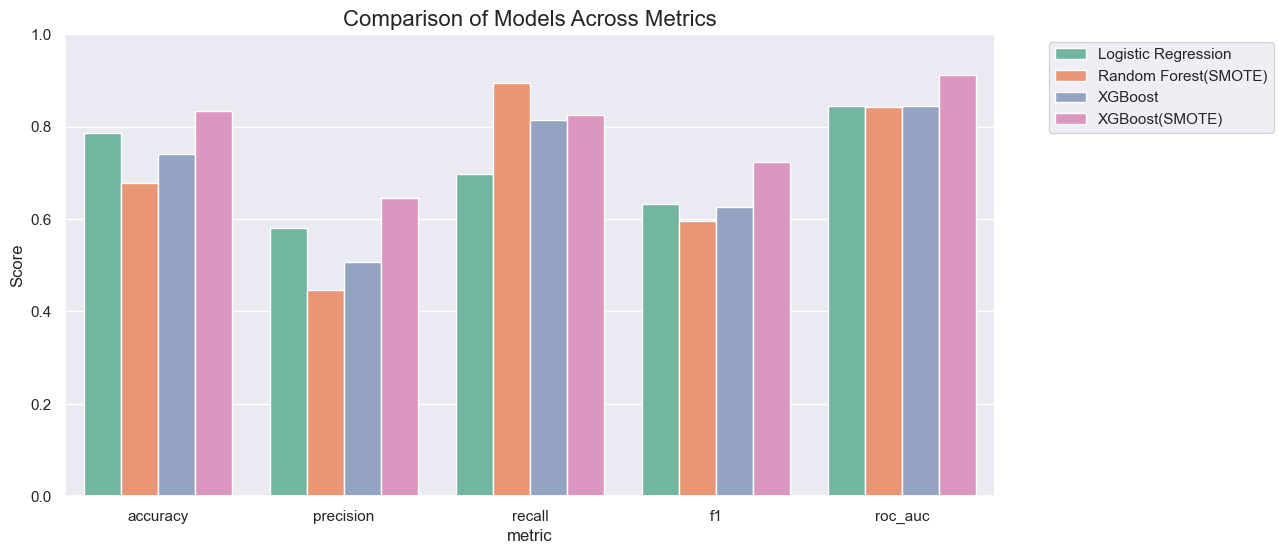

In [282]:
df_melt = model_res.melt(id_vars="model", var_name="metric", value_name="score")

plt.figure(figsize=(12,6))
sns.barplot(data=df_melt, x="metric", y="score", hue="model", palette="Set2")
plt.title("Comparison of Models Across Metrics", fontsize=16)
plt.ylabel("Score")
plt.ylim(0,1)  
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## **Descision:**

* Overall the best predictive model is XGBoost using SMOTE technique, with:
    - Accuracy : 0.8332
    - Precision: 0.6449
    - Recall   : 0.8261
    - F1 Score : 0.7244
    - ROC-AUC  : 0.9124